# Implementing a Sentence Transformer Model

03/31/2025

This notebook created for the technical assessment for Fetch, a rewards point service.

This notebook performs exploratory data analysis on a few datasets made available through Huggingface and other sources. The idea is to explore these datasets before they get used in the other notebooks for similarity search and named entity recognition.

The documentation for this library may be found here: https://www.sbert.net/

# Step 1: Implement a Sentence Transformer Model

I am going to install a number of natural language processing libraries, in order to perform preliminary Exploratory Data Analysis to find datasets that would be good to explore for classification and named entity recognition.

In [1]:
!pip install -U sentence-transformers
!pip install datasets
!pip install transformers
!pip install evaluate
!pip install seqeval

In [2]:
import numpy as np
import pandas as pd
from datasets import load_dataset, DatasetDict
import nltk
from nltk.tokenize import PunktTokenizer
import seaborn
import matplotlib.pyplot as plt


In [3]:
def annotate_boxplot(seaborn_boxplot, data_input, x_column, y_column):

  min_value = 0
  first_quartile_value = 0
  mean_value = 0
  third_quartile_value = 0
  max_value = 0

  x_column_values = data_input[x_column].unique()
  print(x_column)
  print(y_column)
  print(x_column_values)

  for x_value in x_column_values:
    min_value = data_input[data_input[x_column] == x_value][y_column].min()
    first_quartile_value = data_input[data_input[x_column] == x_value][y_column].quantile(0.25)
    median_value = data_input[data_input[x_column] == x_value][y_column].quantile(0.50)
    third_quartile_value = data_input[data_input[x_column] == x_value][y_column].quantile(0.75)
    max_value = data_input[data_input[x_column] == x_value][y_column].max()

    interquartile_range = third_quartile_value - first_quartile_value
    first_whisker_value = first_quartile_value - (1.5 * interquartile_range)
    last_whisker_value = third_quartile_value + (1.5 * interquartile_range)

    print("""Box plot values for label: {}, \n
            minimum value: {}, \n
            first whisker value: {}, \n
            first quartile value: {}, \n
            median value: {}, \n
            third quartile value: {}, \n
            last whisker value: {}, \n
            max_value: {}""".format(x_value, min_value, first_whisker_value, first_quartile_value, median_value, third_quartile_value, last_whisker_value, max_value))

    seaborn_boxplot.annotate(str(min_value), xy=(x_value, min_value-0.1), ha='right')

    seaborn_boxplot.annotate(str(first_whisker_value), xy=(x_value, first_whisker_value-0.1), ha='right')

    seaborn_boxplot.annotate(str(first_quartile_value), xy=(x_value, first_quartile_value-0.1), ha='right')

    seaborn_boxplot.annotate(str(median_value), xy=(x_value, median_value), ha='right')

    seaborn_boxplot.annotate(str(third_quartile_value), xy=(x_value, third_quartile_value-0.1), ha='right')

    seaborn_boxplot.annotate(str(last_whisker_value), xy=(x_value, last_whisker_value-0.1), ha='right')

    seaborn_boxplot.annotate(str(max_value), xy=(x_value, max_value), ha='right')


  #for i in range(len(data_input.Max)):
  #  seaborn_box.annotate(str(data_input.Max[i]), xy=(data_input.Max[i]+0.1,i), ha='left')

  plt.show()

  return

In [4]:
# Importing "IMDb" dataset from Huggingface
imdb_ds = load_dataset("imdb")

# Initialize the NLTK Sentence Tokenizer
nltk.download('punkt_tab')
sentence_tokenizer = PunktTokenizer()

# Display the structure of the dataset
print(imdb_ds)

# Display the 'training' split of the dataset
print(imdb_ds["train"])


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [5]:
# I convert each dataset subset into pandas DataFrames
# This includes the 'train' subset for training, 'test' subset for testing, and the 'unsupervised' subset in order to find out what it is for.
imdb_train_ds = imdb_ds["train"].to_pandas()
imdb_test_ds = imdb_ds["test"].to_pandas()
imdb_unsupervised_ds = imdb_ds["unsupervised"].to_pandas()


I want to perform a few different explorations on the data.
- To find out how many "labels" there are per dataset.
- I want to find out the distribution of how many samples there are for each label.
- I want to find out how many sentences there are in each 'text.' For this, I will use the Punkt sentence tokenizer from NLTK. https://www.nltk.org/api/nltk.tokenize.punkt.html

In [6]:
imdb_train_ds.head(10)

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0
5,I would put this at the top of my list of film...,0
6,Whoever wrote the screenplay for this movie ob...,0
7,"When I first saw a glimpse of this movie, I qu...",0
8,"Who are these ""They""- the actors? the filmmake...",0
9,This is said to be a personal film for Peter B...,0


In [7]:
imdb_train_ds['label'].unique()

array([0, 1])

I am going to copy the label column into a new column, and convert the numeric values into categorical labels:

- 0 - Negative Review
- 1 - Postive Postive Review

In [8]:
imdb_train_ds['review_value'] = imdb_train_ds['label'].replace({0: 'Negative Review', 1: 'Positive Review'})

Data split visualizations
- Histogram plots for the entirety of the data
- Box plots for the data
- Initial splits
- Final splits

Then do write-ups of opinions and findings

In [9]:
tokenized_sentences_results = []
num_sentences = 0

for entry in imdb_train_ds['text']:
  result_tokens = sentence_tokenizer.tokenize(entry)
  num_sentences = len(result_tokens)
  tokenized_sentences_results.append([result_tokens, num_sentences])

tokenized_sentences_train_ds = pd.DataFrame(data=tokenized_sentences_results, columns=["split_sentences", "num_sentences"])

imdb_train_ds_with_sentences = imdb_train_ds.join(tokenized_sentences_train_ds, how="outer")

# I take a moment to reorganize the column order of the dataframe, so that label is the final column.
imdb_train_ds_with_sentences = imdb_train_ds_with_sentences.reindex(columns=['text', 'split_sentences', 'num_sentences', 'label', 'review_value'])
print(imdb_train_ds_with_sentences.head())

                                                text  \
0  I rented I AM CURIOUS-YELLOW from my video sto...   
1  "I Am Curious: Yellow" is a risible and preten...   
2  If only to avoid making this type of film in t...   
3  This film was probably inspired by Godard's Ma...   
4  Oh, brother...after hearing about this ridicul...   

                                     split_sentences  num_sentences  label  \
0  [I rented I AM CURIOUS-YELLOW from my video st...              9      0   
1  ["I Am Curious: Yellow" is a risible and prete...             11      0   
2  [If only to avoid making this type of film in ...              3      0   
3  [This film was probably inspired by Godard's M...              7      0   
4  [Oh, brother...after hearing about this ridicu...              6      0   

      review_value  
0  Negative Review  
1  Negative Review  
2  Negative Review  
3  Negative Review  
4  Negative Review  


<Axes: xlabel='num_sentences', ylabel='Count'>

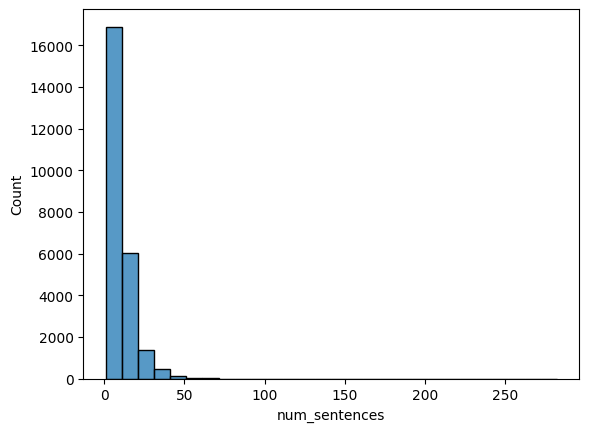

In [10]:
seaborn.histplot(imdb_train_ds_with_sentences, x="num_sentences", binwidth=10)

review_value
num_sentences
['Negative Review' 'Positive Review']
Box plot values for label: Negative Review, 

            minimum value: 1, 

            first whisker value: -4.5, 

            first quartile value: 6.0, 

            median value: 9.0, 

            third quartile value: 13.0, 

            last whisker value: 23.5, 

            max_value: 118
Box plot values for label: Positive Review, 

            minimum value: 1, 

            first whisker value: -4.5, 

            first quartile value: 6.0, 

            median value: 9.0, 

            third quartile value: 13.0, 

            last whisker value: 23.5, 

            max_value: 282


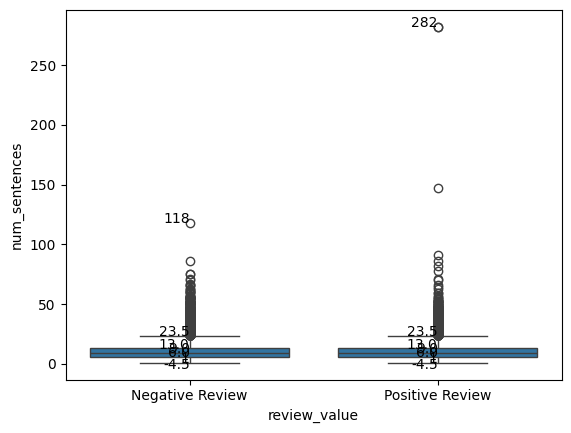

In [11]:
box_plot = seaborn.boxplot(imdb_train_ds_with_sentences, x="review_value", y="num_sentences")
annotate_boxplot(box_plot, imdb_train_ds_with_sentences, x_column="review_value", y_column="num_sentences")

Based on the above plot, I will split the data into two subsets. One that has reviews that are shorter than a certain threshold of sentences, and one that has reviews longer than a certain threshold of sentences.

For this discretization, I will choose a threshold of 50 sentences.

review_value
num_sentences
['Negative Review' 'Positive Review']
Box plot values for label: Negative Review, 

            minimum value: 1, 

            first whisker value: -3.0, 

            first quartile value: 6.0, 

            median value: 9.0, 

            third quartile value: 12.0, 

            last whisker value: 21.0, 

            max_value: 25
Box plot values for label: Positive Review, 

            minimum value: 1, 

            first whisker value: -3.0, 

            first quartile value: 6.0, 

            median value: 8.0, 

            third quartile value: 12.0, 

            last whisker value: 21.0, 

            max_value: 25


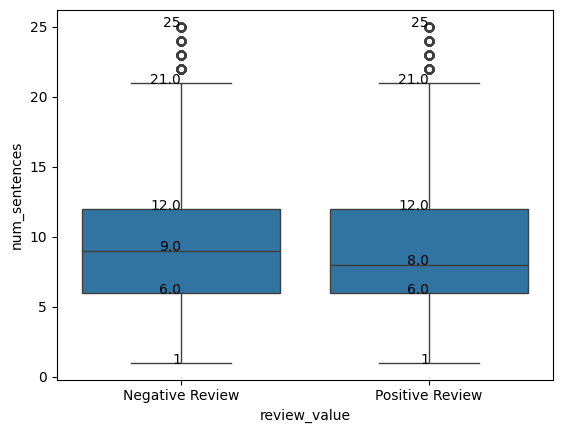

In [12]:
between_0_and_25_sentences_train_boolean_mask =  ( imdb_train_ds_with_sentences["num_sentences"] >=  0 ) & (imdb_train_ds_with_sentences["num_sentences"] <= 25)
between_0_and_25_sentences_imdb_train_ds = imdb_train_ds_with_sentences[between_0_and_25_sentences_train_boolean_mask]

between_0_and_25_sentences_train_boxplot = seaborn.boxplot(between_0_and_25_sentences_imdb_train_ds, x="review_value", y="num_sentences", legend="full")
annotate_boxplot(between_0_and_25_sentences_train_boxplot, between_0_and_25_sentences_imdb_train_ds, x_column="review_value", y_column="num_sentences")

From the above box plot, creating two discrete sets of data from the overall dataset using a threshold of 50 still

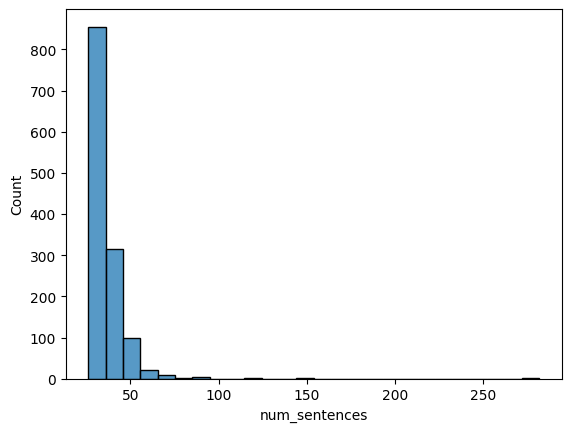

In [13]:
greater_than_25_sentences_imdb_train_ds = imdb_train_ds_with_sentences[~between_0_and_25_sentences_train_boolean_mask]

hist_plot = seaborn.histplot(greater_than_25_sentences_imdb_train_ds, x="num_sentences", binwidth=10)

review_value
num_sentences
['Negative Review' 'Positive Review']
Box plot values for label: Negative Review, 

            minimum value: 26, 

            first whisker value: 10.0, 

            first quartile value: 28.0, 

            median value: 32.0, 

            third quartile value: 40.0, 

            last whisker value: 58.0, 

            max_value: 118
Box plot values for label: Positive Review, 

            minimum value: 26, 

            first whisker value: 13.0, 

            first quartile value: 28.0, 

            median value: 32.0, 

            third quartile value: 38.0, 

            last whisker value: 53.0, 

            max_value: 282


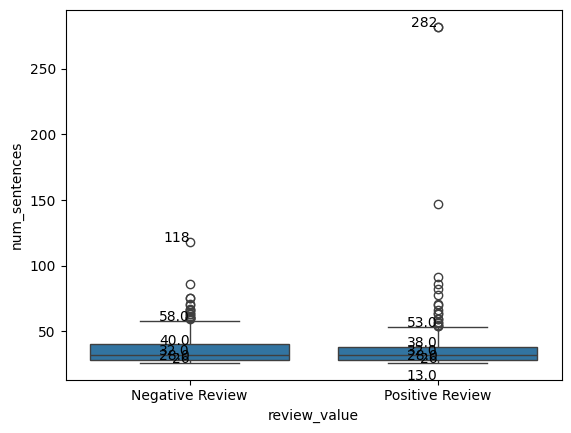

In [14]:
greater_than_25_sentences_train_boxplot = seaborn.boxplot(greater_than_25_sentences_imdb_train_ds, x="review_value", y="num_sentences")
annotate_boxplot(greater_than_25_sentences_train_boxplot, greater_than_25_sentences_imdb_train_ds, x_column="review_value", y_column="num_sentences")

review_value
num_sentences
['Negative Review' 'Positive Review']
Box plot values for label: Negative Review, 

            minimum value: 26, 

            first whisker value: 13.0, 

            first quartile value: 28.0, 

            median value: 32.0, 

            third quartile value: 38.0, 

            last whisker value: 53.0, 

            max_value: 55
Box plot values for label: Positive Review, 

            minimum value: 26, 

            first whisker value: 14.5, 

            first quartile value: 28.0, 

            median value: 31.0, 

            third quartile value: 37.0, 

            last whisker value: 50.5, 

            max_value: 55


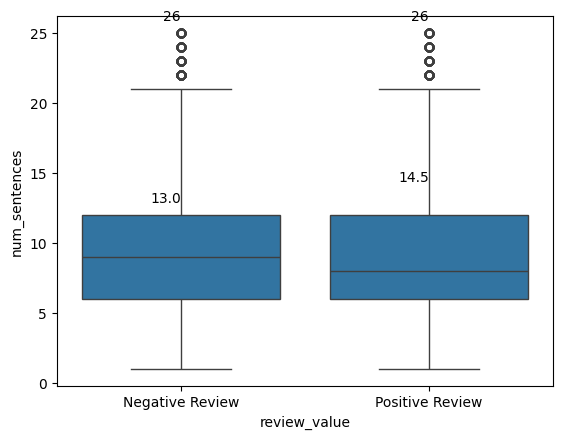

In [15]:
between_25_and_55_sentences_train_boolean_mask =  ( imdb_train_ds_with_sentences["num_sentences"] >  25 ) & (imdb_train_ds_with_sentences["num_sentences"] <= 55)
between_25_and_55_sentences_imdb_train_ds = imdb_train_ds_with_sentences[between_25_and_55_sentences_train_boolean_mask]

between_25_and_55_sentences_train_boxplot = seaborn.boxplot(between_0_and_25_sentences_imdb_train_ds, x="review_value", y="num_sentences", legend="full")
annotate_boxplot(between_25_and_55_sentences_train_boxplot, between_25_and_55_sentences_imdb_train_ds, x_column="review_value", y_column="num_sentences")

review_value
num_sentences
['Negative Review' 'Positive Review']
Box plot values for label: Negative Review, 

            minimum value: 56, 

            first whisker value: 44.5, 

            first quartile value: 58.0, 

            median value: 62.0, 

            third quartile value: 67.0, 

            last whisker value: 80.5, 

            max_value: 118
Box plot values for label: Positive Review, 

            minimum value: 56, 

            first whisker value: 24.125, 

            first quartile value: 62.0, 

            median value: 70.5, 

            third quartile value: 87.25, 

            last whisker value: 125.125, 

            max_value: 282


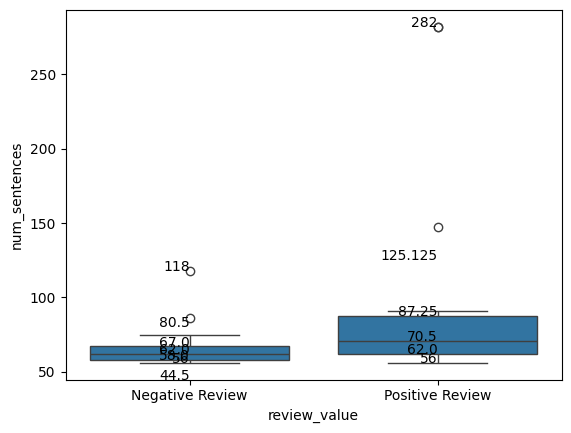

In [16]:
greater_than_55_sentences_train_boolean_mask =  imdb_train_ds_with_sentences["num_sentences"] > 55

greater_than_55_sentences_imdb_train_ds = imdb_train_ds_with_sentences[greater_than_55_sentences_train_boolean_mask]

greater_than_55_sentences_train_boxplot = seaborn.boxplot(greater_than_55_sentences_imdb_train_ds, x="review_value", y="num_sentences", legend="full")
annotate_boxplot(greater_than_55_sentences_train_boxplot, greater_than_55_sentences_imdb_train_ds, x_column="review_value", y_column="num_sentences")

<Axes: xlabel='num_sentences', ylabel='Count'>

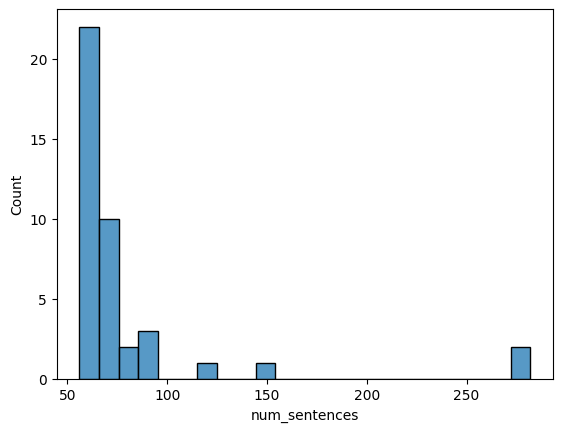

In [17]:
seaborn.histplot(greater_than_55_sentences_imdb_train_ds, x="num_sentences", binwidth=10)

In [18]:
imdb_test_ds.head(10)

,text,label
0,I love sci-fi and am willing to put up with a ...,0
1,"Worth the entertainment value of a rental, esp...",0
2,its a totally average film with a few semi-alr...,0
3,STAR RATING: ***** Saturday Night **** Friday ...,0
4,"First off let me say, If you haven't enjoyed a...",0
5,I had high hopes for this one until they chang...,0
6,Isaac Florentine has made some of the best wes...,0
7,"It actually pains me to say it, but this movie...",0
8,"Technically I'am a Van Damme Fan, or I was. th...",0
9,"Honestly awful film, bad editing, awful lighti...",0


In [19]:
imdb_test_ds['label'].unique()

array([0, 1])

In [20]:
imdb_test_ds['review_value'] = imdb_test_ds['label'].replace({0: 'Negative Review', 1: 'Positive Review'})

In [21]:
tokenized_sentences_results = []
num_sentences = 0

for entry in imdb_test_ds['text']:
  result_tokens = sentence_tokenizer.tokenize(entry)
  num_sentences = len(result_tokens)
  tokenized_sentences_results.append([result_tokens, num_sentences])

tokenized_sentences_test_df = pd.DataFrame(data=tokenized_sentences_results, columns=["split_sentences", "num_sentences"])

imdb_test_ds_with_sentences = imdb_test_ds.join(tokenized_sentences_test_df, how="outer")

# I take a moment to reorganize the column order of the dataframe, so that label is the final column.
imdb_test_ds_with_sentences = imdb_test_ds_with_sentences.reindex(columns=['text', 'split_sentences', 'num_sentences', 'label', 'review_value'])
print(imdb_test_ds_with_sentences.head())

                                                text  \
0  I love sci-fi and am willing to put up with a ...   
1  Worth the entertainment value of a rental, esp...   
2  its a totally average film with a few semi-alr...   
3  STAR RATING: ***** Saturday Night **** Friday ...   
4  First off let me say, If you haven't enjoyed a...   

                                     split_sentences  num_sentences  label  \
0  [I love sci-fi and am willing to put up with a...             19      0   
1  [Worth the entertainment value of a rental, es...             11      0   
2  [its a totally average film with a few semi-al...              5      0   
3  [STAR RATING: ***** Saturday Night **** Friday...             11      0   
4  [First off let me say, If you haven't enjoyed ...              7      0   

      review_value  
0  Negative Review  
1  Negative Review  
2  Negative Review  
3  Negative Review  
4  Negative Review  


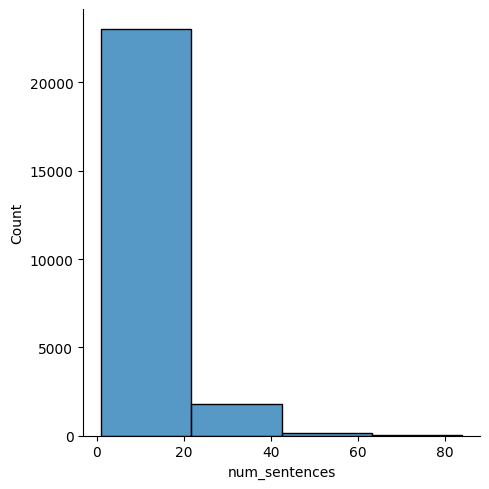

In [22]:
seaborn.displot(imdb_test_ds_with_sentences, x="num_sentences", binwidth=20)

review_value
num_sentences
['Negative Review' 'Positive Review']
Box plot values for label: Negative Review, 

            minimum value: 1, 

            first whisker value: -4.5, 

            first quartile value: 6.0, 

            median value: 9.0, 

            third quartile value: 13.0, 

            last whisker value: 23.5, 

            max_value: 84
Box plot values for label: Positive Review, 

            minimum value: 1, 

            first whisker value: -4.5, 

            first quartile value: 6.0, 

            median value: 8.0, 

            third quartile value: 13.0, 

            last whisker value: 23.5, 

            max_value: 80


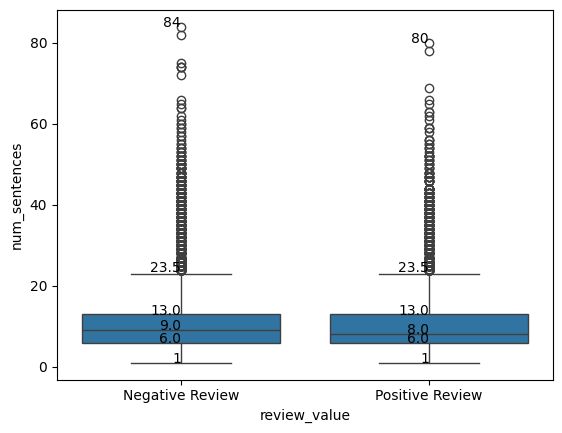

In [23]:
test_boxplot = seaborn.boxplot(imdb_test_ds_with_sentences, x="review_value", y="num_sentences")
annotate_boxplot(test_boxplot, imdb_test_ds_with_sentences, x_column="review_value", y_column="num_sentences")

review_value
num_sentences
['Negative Review' 'Positive Review']
Box plot values for label: Negative Review, 

            minimum value: 1, 

            first whisker value: -3.0, 

            first quartile value: 6.0, 

            median value: 9.0, 

            third quartile value: 12.0, 

            last whisker value: 21.0, 

            max_value: 25
Box plot values for label: Positive Review, 

            minimum value: 1, 

            first whisker value: -3.0, 

            first quartile value: 6.0, 

            median value: 8.0, 

            third quartile value: 12.0, 

            last whisker value: 21.0, 

            max_value: 25


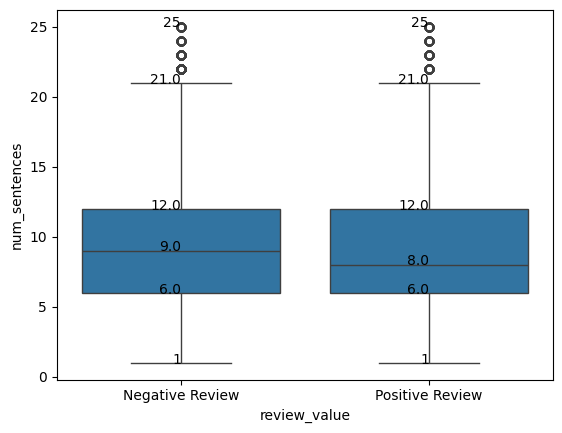

In [24]:
between_0_and_25_sentences_test_boolean_mask =  ( imdb_test_ds_with_sentences["num_sentences"] >=  0 ) & (imdb_test_ds_with_sentences["num_sentences"] <= 25)
between_0_and_25_sentences_imdb_test_ds = imdb_test_ds_with_sentences[between_0_and_25_sentences_test_boolean_mask]

between_0_and_25_sentences_test_boxplot = seaborn.boxplot(between_0_and_25_sentences_imdb_test_ds, x="review_value", y="num_sentences", legend="full")
annotate_boxplot(between_0_and_25_sentences_test_boxplot, between_0_and_25_sentences_imdb_test_ds, x_column="review_value", y_column="num_sentences")

review_value
num_sentences
['Negative Review' 'Positive Review']
Box plot values for label: Negative Review, 

            minimum value: 26, 

            first whisker value: 11.5, 

            first quartile value: 28.0, 

            median value: 32.0, 

            third quartile value: 39.0, 

            last whisker value: 55.5, 

            max_value: 84
Box plot values for label: Positive Review, 

            minimum value: 26, 

            first whisker value: 13.0, 

            first quartile value: 28.0, 

            median value: 32.0, 

            third quartile value: 38.0, 

            last whisker value: 53.0, 

            max_value: 80


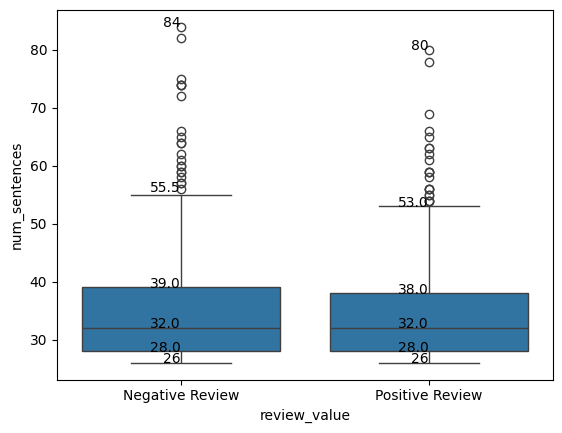

In [25]:
greater_than_25_sentences_imdb_test_ds = imdb_test_ds_with_sentences[~between_0_and_25_sentences_test_boolean_mask]

greater_than_25_sentences_test_boxplot = seaborn.boxplot(greater_than_25_sentences_imdb_test_ds, x="review_value", y="num_sentences")
annotate_boxplot(greater_than_25_sentences_test_boxplot, greater_than_25_sentences_imdb_test_ds, x_column="review_value", y_column="num_sentences")

review_value
num_sentences
['Negative Review' 'Positive Review']
Box plot values for label: Negative Review, 

            minimum value: 56, 

            first whisker value: 36.5, 

            first quartile value: 59.0, 

            median value: 64.0, 

            third quartile value: 74.0, 

            last whisker value: 96.5, 

            max_value: 84
Box plot values for label: Positive Review, 

            minimum value: 56, 

            first whisker value: 49.0, 

            first quartile value: 58.75, 

            median value: 61.5, 

            third quartile value: 65.25, 

            last whisker value: 75.0, 

            max_value: 80


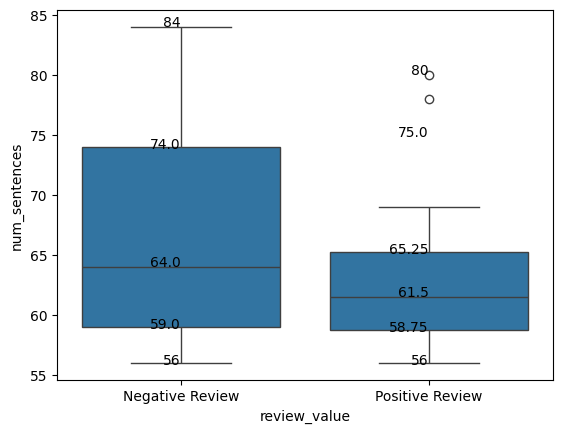

In [26]:
greater_than_55_sentences_test_boolean_mask =  imdb_test_ds_with_sentences["num_sentences"] > 55

greater_than_55_sentences_imdb_test_ds = imdb_test_ds_with_sentences[greater_than_55_sentences_test_boolean_mask]

greater_than_55_sentences_test_boxplot = seaborn.boxplot(greater_than_55_sentences_imdb_test_ds, x="review_value", y="num_sentences", legend="full")
annotate_boxplot(greater_than_55_sentences_test_boxplot, greater_than_55_sentences_imdb_test_ds, x_column="review_value", y_column="num_sentences")

In [27]:
imdb_unsupervised_ds.head()

,text,label
0,This is just a precious little diamond. The pl...,-1
1,When I say this is my favourite film of all ti...,-1
2,I saw this movie because I am a huge fan of th...,-1
3,Being that the only foreign films I usually li...,-1
4,After seeing Point of No Return (a great movie...,-1


In [28]:
imdb_unsupervised_ds['label'].unique()

array([-1])

                                                text  label  \
0  This is just a precious little diamond. The pl...     -1   
1  When I say this is my favourite film of all ti...     -1   
2  I saw this movie because I am a huge fan of th...     -1   
3  Being that the only foreign films I usually li...     -1   
4  After seeing Point of No Return (a great movie...     -1   

                                     split_sentences  num_sentences  \
0  [This is just a precious little diamond., The ...             14   
1  [When I say this is my favourite film of all t...             11   
2  [I saw this movie because I am a huge fan of t...              4   
3  [Being that the only foreign films I usually l...              4   
4  [After seeing Point of No Return (a great movi...              6   

         review_value  
0  Value Not Provided  
1  Value Not Provided  
2  Value Not Provided  
3  Value Not Provided  
4  Value Not Provided  
                                                te

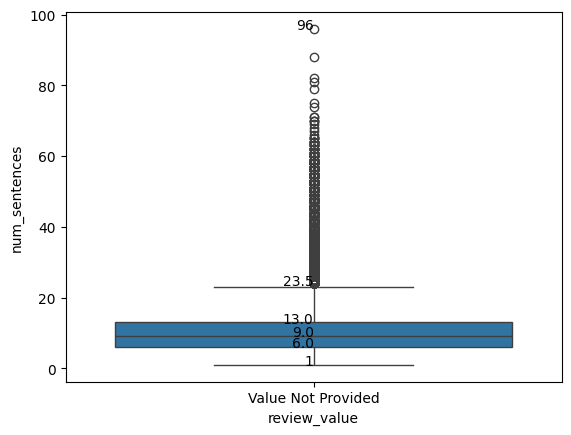

In [29]:
tokenized_sentences_results = []
num_sentences = 0

for entry in imdb_unsupervised_ds['text']:
  result_tokens = sentence_tokenizer.tokenize(entry)
  num_sentences = len(result_tokens)
  tokenized_sentences_results.append([result_tokens, num_sentences])

tokenized_sentences_unsupervised_df = pd.DataFrame(data=tokenized_sentences_results, columns=["split_sentences", "num_sentences"])

imdb_unsupervised_ds_with_sentences = imdb_unsupervised_ds.join(tokenized_sentences_unsupervised_df, how="outer")

imdb_unsupervised_ds_with_sentences['review_value'] = imdb_unsupervised_ds_with_sentences['label'].replace({-1: 'Value Not Provided'})

print(imdb_unsupervised_ds_with_sentences.head())
imdb_unsupervised_ds_with_sentences = imdb_unsupervised_ds_with_sentences.reindex(columns=['text', 'split_sentences', 'num_sentences', 'label', 'review_value'])

print(imdb_unsupervised_ds_with_sentences.head())
# seaborn.displot(imdb_unsupervised_ds_with_sentences, x="num_sentences", binwidth=20)
unsupervised_boxplot = seaborn.boxplot(imdb_unsupervised_ds_with_sentences, x="review_value", y="num_sentences")
annotate_boxplot(unsupervised_boxplot, imdb_unsupervised_ds_with_sentences, x_column="review_value", y_column="num_sentences")